### Text Descriptors

In [25]:
# all necessary imports are listed below
import os
import random
import cv2
import matplotlib.pyplot as plt
import re
import psycopg2
import psycopg2.extras
import unicodedata
import spacy
import wordninja
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from scipy.sparse import hstack
from sklearn.preprocessing import normalize

In [6]:
dataset_path = Path(r'C:\Users\danie\Desktop\_\Daniela Curmi\University\Final Year Project\Final Year Project Code Implementation\Website')

Image Path: C:\Users\danie\Desktop\_\Daniela Curmi\University\Final Year Project\Final Year Project Code Implementation\Website\paintings\Minimalism\ronnie-landfield_series-painting-7-1966.jpg
Genre: Minimalism 
Artist: Ronnie Landfield 
Painting Name: Series Painting 7  
Year: 1966


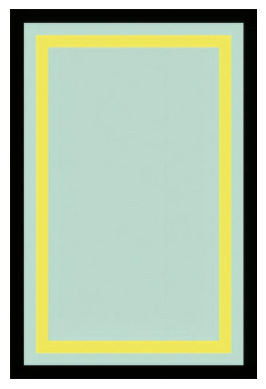

In [70]:
dataset_path_paintings = os.path.join(dataset_path, 'paintings')

# pick a random genre and image 
genre = random.choice(os.listdir(dataset_path_paintings))
rand_genre_path = os.path.join(dataset_path_paintings, genre)
rand_img = random.choice(os.listdir(rand_genre_path))
img_path = os.path.join(rand_genre_path, rand_img)

image = cv2.imread(img_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# parse filename for genre, artist, painting, and year 
filename = os.path.splitext(rand_img)[0]  
parts = filename.split("_")                

artist_part = parts[0]
painting_part = "_".join(parts[1:])
match = re.search(r"\b\d{4}\b", painting_part)
if match:
    year = match.group(0)
    painting_part = painting_part.replace(year, "").replace("-", " ")
else:
    year = "Unknown"
    painting_part = painting_part.replace("-", " ")

# clean up outputs and display results
genre = genre.replace("_", " ").title()
artist = artist_part.replace("-", " ").title()
painting_name = painting_part.replace("-", " ").title()

print("Image Path:", img_path)
print(f"Genre: {genre} \nArtist: {artist} \nPainting Name: {painting_name} \nYear: {year}")

plt.imshow(image_rgb)
plt.axis("off")
plt.show()

In [4]:
def text_features(img_path):    
    image = cv2.imread(img_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # parse filename for genre, artist, painting, and year 
    genre = os.path.basename(os.path.dirname(img_path))
    filename = os.path.splitext(os.path.basename(img_path))[0] 
    parts = filename.split("_")                

    artist_part = parts[0]
    painting_part = "_".join(parts[1:])
    match = re.search(r"\b\d{4}\b", painting_part)
    if match:
        year = match.group(0)
        painting_part = painting_part.replace(year, "").replace("-", " ")
    else:
        year = "Unknown"
        painting_part = painting_part.replace("-", " ")

    # clean up outputs and display results
    genre = genre.replace("_", " ").title()
    artist = artist_part.replace("-", " ").title()
    painting_name = painting_part.replace("-", " ").title()

    return image_rgb, genre, artist, genre, painting_name, year

### Database Text Descriptors 

In [7]:
# Extract Artist and Painting Metadata from ART_RECSYS_DB to be used for TF-IDF VSM, BERT, and CLIP

# Database connection
def get_db_connection():
    conn = psycopg2.connect(
        host="localhost",
        database="ART_RECSYS_DB",
        user="postgres",
        password="Catmelon304!"
    )
    return conn

get_db_connection()

<connection object at 0x0000024C8E9BA570; dsn: 'user=postgres password=xxx dbname=ART_RECSYS_DB host=localhost', closed: 0>

In this Notebook I will be cover the Implementation of a TF-IDF VSM and k-NN BERT Recommendation Architectures. Sections will comprise of Preprocessing per architecture, Painting Metadata representation, and the final Recommendation Strategy.

## Preprocessing

### Data Validation 

#### Checking for Invalid Data and Cleaning

In [20]:
# Validation for meta data before cleaning 
def validate_all_paintings():
    conn = get_db_connection()
    cur = conn.cursor(cursor_factory=psycopg2.extras.RealDictCursor)

    # Fetch all paintings with the required fields only
    cur.execute("""
        SELECT
            painting_id,
            year_created,
            birth_year,
            death_year
        FROM paintings_and_artists_metadata_tf_idf
    """)

    rows = cur.fetchall()
    cur.close()
    conn.close()

    validation_results = []

    for row in rows:
        errors = []
        pid = row["painting_id"]

        # Year validation
        year = row["year_created"]
        if year is not None:
            if not (1000 <= year <= 2026):
                errors.append("invalid_year_created")

        # Artist lifespan consistency
        birth = row["birth_year"]
        death = row["death_year"]
        if birth is not None and death is not None:
            if birth > death:
                errors.append("invalid_lifespan")

        # Painting before artist birth
        if year is not None and birth is not None:
            if year < birth:
                errors.append("painting_before_birth")

        if errors:
            validation_results.append({
                "painting_id": pid,
                "title": row["title"],
                "errors": errors
            })

    return validation_results

validation_results = validate_all_paintings()
print(validation_results)

[]


#### Extracting Year from Title, Wrong Year from Title, Wrong Year and Removed

In [ ]:
# Resolve 'invalid_year_created' and 'painting_before_birth'
def extract_year_from_title(title):
    if not title:
        return None

    # Match years between 1000–2026
    matches = re.findall(r"\b(1[0-9]{3}|20[0-2][0-6])\b", title)

    if not matches:
        return None

    return int(matches[-1])

def fix_years_from_titles(paintings_with_errors):
    conn = get_db_connection()
    cur = conn.cursor(cursor_factory=psycopg2.extras.RealDictCursor)

    for item in paintings_with_errors:
        pid = item["painting_id"]
        title = item["title"]

        extracted_year = extract_year_from_title(title)

        if extracted_year:
            print(f"Updating painting {pid}: setting year_created to {extracted_year}")

            cur.execute("""
                UPDATE paintings_and_artists_metadata_tf_idf
                SET year_created = %s
                WHERE painting_id = %s
            """, (extracted_year, pid))
        else:
            print(f"Skipping painting {pid}: no valid year found in title")

    conn.commit()
    cur.close()
    conn.close()

fix_years_from_titles(validation_results)

Updating painting 103: setting year_created to 1985
Updating painting 104: setting year_created to 1991
Updating painting 105: setting year_created to 1984
Updating painting 106: setting year_created to 1984
Updating painting 114: setting year_created to 1960
Updating painting 117: setting year_created to 1962
Skipping painting 924: no valid year found in title
Skipping painting 1319: no valid year found in title
Updating painting 2257: setting year_created to 1985
Updating painting 2431: setting year_created to 1972
Updating painting 2434: setting year_created to 1975
Skipping painting 2530: no valid year found in title
Skipping painting 3234: no valid year found in title
Updating painting 3624: setting year_created to 1912
Updating painting 3844: setting year_created to 1908
Skipping painting 3881: no valid year found in title
Updating painting 3894: setting year_created to 1952
Updating painting 4124: setting year_created to 1896
Updating painting 4256: setting year_created to 1908


In [ ]:
# Resolve 'invalid_year_created' and 'painting_before_birth'
wrong_year_move_to_title  = [{'painting_id': 3234,
  'title': 'Prince Ukhtomsky In The Battle With Tartars At Volga In  ',
  'errors': ['painting_before_birth']},
 {'painting_id': 3881,
  'title': 'The Life Of St Ignatius Loyola Plate 10 The Death Of St Ignatius 31St July  ',
  'errors': ['painting_before_birth']},
 {'painting_id': 5278,
  'title': 'Design For The  Piastres Porto Brand Of Austrian Post In The Levant Not Issued',
  'errors': ['painting_before_birth']},
 {'painting_id': 15055,
  'title': 'Aleksandra Ekster Costume Designs For A  Production Of Salome',
  'errors': ['painting_before_birth']},
 {'painting_id': 18191,
  'title': 'Founding Act Of The Municipal Savings Bank Of Vitoria In  ',
  'errors': ['painting_before_birth']},
 {'painting_id': 18319, 'title': 'P ', 'errors': ['invalid_year_created']},
 {'painting_id': 46503,
  'title': 'Crusaders Arrived In Constantinople Battle Between The French And Turks In  And 1148',
  'errors': ['painting_before_birth']},
 {'painting_id': 46517,
  'title': 'Entry Of Louis Vii C  80 King Of France And Conrad Iii 1093 1152 King Of Germany Into',
  'errors': ['painting_before_birth']},
 {'painting_id': 46563,
  'title': 'The Arrival Of Charles V  80 In Paris 28Th May 1364',
  'errors': ['painting_before_birth']},
 {'painting_id': 39665,
  'title': 'Catherine Of Siena Escorted Pope Gregory Xi At Rome On 17Th January  ',
  'errors': ['painting_before_birth']},
  {'painting_id': 69406,
  'title': 'The Preaching Of John Knox Before The Lords Of Congregation 10 June  ',
  'errors': ['painting_before_birth']},
 {'painting_id': 69872,
  'title': 'First Observation Of The Transit Of Venus By William Crabtree In  ',
  'errors': ['painting_before_birth']},
 {'painting_id': 69901,
  'title': 'The Proclamation Regarding Weights And Measures  Illustration From Hutchinson S Story Of',
  'errors': ['painting_before_birth']},
 {'painting_id': 71490,
  'title': 'Chopin Performing In The Guest Hall Of Anton Radziville In Berlin In  ',
  'errors': ['painting_before_birth']},
 {'painting_id': 73536,
  'title': 'Proclamation Of Kuzma Minin In Nizhny Novgorod In  ',
  'errors': ['painting_before_birth']},
 {'painting_id': 77134,
  'title': 'Parade In The  ',
  'errors': ['painting_before_birth']},
  {'painting_id': 49648,
  'title': 'Unknown  ',
  'errors': ['painting_before_birth']},
 {'painting_id': 60771,
  'title': 'Statesmen No  Caricature Of The Rt Hon Cp Villiers M P',
  'errors': ['painting_before_birth']},
 {'painting_id': 60772,
  'title': 'Statesmen No  ',
  'errors': ['painting_before_birth']},
 {'painting_id': 60773,
  'title': 'Statesmen No  Caricature Of The Rt Hon Hbw Brand M P',
  'errors': ['painting_before_birth']},
 {'painting_id': 60774,
  'title': 'Statesmen No  Caricature Of Mr Roger Eykyn Liberal M P For Windsor',
  'errors': ['painting_before_birth']},
 {'painting_id': 60775,
  'title': 'Statesmen No  Caricature Of Sir Francis Goldsmid M P',
  'errors': ['painting_before_birth']},
 {'painting_id': 66648,
  'title': 'The Battle Of La Hogue Destruction Of The French Fleet May 22  Detail',
  'errors': ['painting_before_birth']},
 {'painting_id': 66649,
  'title': 'The Battle Of La Hogue Destruction Of The French Fleet May 22  ',
  'errors': ['painting_before_birth']}]

def insert_year_into_title(title, year):
    if not title or not year:
        return title

    year_str = str(year)

    # If double space exists then insert year there
    if "  " in title:
        new_title = title.replace("  ", f" {year_str} ", 1)
    
    # If ends with space then append at the end
    elif title.endswith(" "):
        new_title = title + year_str
    
    # fallback
    else:
        new_title = f"{title} {year_str}"

    # Clean extra whitespace
    new_title = re.sub(r"\s+", " ", new_title).strip()

    return new_title

def move_year_to_title(paintings_list):
    conn = get_db_connection()
    cur = conn.cursor(cursor_factory=psycopg2.extras.RealDictCursor)

    for item in paintings_list:
        pid = item["painting_id"]

        # Fetch current title + year
        cur.execute("""
            SELECT title, year_created
            FROM paintings_and_artists_metadata_tf_idf
            WHERE painting_id = %s
        """, (pid,))
        
        row = cur.fetchone()
        if not row:
            print(f"Skipping {pid}: not found")
            continue

        title = row["title"]
        year = row["year_created"]

        if not year:
            print(f"Skipping {pid}: no year to move")
            continue

        new_title = insert_year_into_title(title, year)

        print(f"{pid}: '{title}' → '{new_title}'")

        # Update DB
        cur.execute("""
            UPDATE paintings_and_artists_metadata_tf_idf
            SET title = %s,
                year_created = NULL
            WHERE painting_id = %s
        """, (new_title, pid))

    conn.commit()
    cur.close()
    conn.close()

move_year_to_title(wrong_year_move_to_title)

3234: 'Prince Ukhtomsky In The Battle With Tartars At Volga In ' → 'Prince Ukhtomsky In The Battle With Tartars At Volga In 1469'
3881: 'The Life Of St Ignatius Loyola Plate 10 The Death Of St Ignatius 31St July ' → 'The Life Of St Ignatius Loyola Plate 10 The Death Of St Ignatius 31St July 1556'
5278: 'Design For The  Piastres Porto Brand Of Austrian Post In The Levant Not Issued' → 'Design For The 1102 Piastres Porto Brand Of Austrian Post In The Levant Not Issued'
15055: 'Aleksandra Ekster Costume Designs For A  Production Of Salome' → 'Aleksandra Ekster Costume Designs For A 1917 Production Of Salome'
18191: 'Founding Act Of The Municipal Savings Bank Of Vitoria In ' → 'Founding Act Of The Municipal Savings Bank Of Vitoria In 1850'
18319: 'P ' → 'P 5533'
46503: 'Crusaders Arrived In Constantinople Battle Between The French And Turks In  And 1148' → 'Crusaders Arrived In Constantinople Battle Between The French And Turks In 1148 And 1148'
46517: 'Entry Of Louis Vii C  80 King Of Fra

In [ ]:
# Resolve 'invalid_year_created' and 'painting_before_birth'
def nullify_invalid_years(validation_results):
    conn = get_db_connection()
    cur = conn.cursor()

    for item in validation_results:
        pid = item["painting_id"]

        cur.execute("""
            UPDATE paintings_and_artists_metadata_tf_idf
            SET year_created = NULL
            WHERE painting_id = %s
        """, (pid,))

        print(f"Set year_created = NULL for painting_id {pid}")

    conn.commit()
    cur.close()
    conn.close()

nullify_invalid_years(validation_results)

Set year_created = NULL for painting_id 924
Set year_created = NULL for painting_id 1319
Set year_created = NULL for painting_id 2530
Set year_created = NULL for painting_id 41546
Set year_created = NULL for painting_id 42825
Set year_created = NULL for painting_id 48910
Set year_created = NULL for painting_id 67146


#### Check for Missing Values for all Metadata fields and Handle Nulls

In [ ]:
# Checking for NULLs/empty cells
def check_nulls_and_empty_cells():
    conn = get_db_connection()
    cur = conn.cursor()

    query = """
    SELECT
        COUNT(*) AS total_rows,

        COUNT(*) FILTER (WHERE title IS NULL OR TRIM(title) = '') AS title_missing,
        COUNT(*) FILTER (WHERE year_created IS NULL) AS year_created_missing,
        COUNT(*) FILTER (WHERE birth_year IS NULL) AS birth_year_missing,
        COUNT(*) FILTER (WHERE death_year IS NULL) AS death_year_missing,
        COUNT(*) FILTER (WHERE genre IS NULL OR TRIM(genre) = '') AS genre_missing,
        COUNT(*) FILTER (WHERE art_style IS NULL OR TRIM(art_style) = '') AS art_style_missing,
        COUNT(*) FILTER (WHERE nationality IS NULL OR TRIM(nationality) = '') AS nationality_missing,
        COUNT(*) FILTER (WHERE artist IS NULL OR TRIM(artist) = '') AS name_missing,
        COUNT(*) FILTER (WHERE media IS NULL OR TRIM(media) = '') AS media_missing,
        COUNT(*) FILTER (WHERE description_tags IS NULL OR TRIM(description_tags) = '') AS description_tags_missing,
        COUNT(*) FILTER (WHERE fields IS NULL OR TRIM(fields) = '') AS fields_missing,
        COUNT(*) FILTER (WHERE art_movements IS NULL OR TRIM(art_movements) = '') AS art_movements_missing,
        COUNT(*) FILTER (WHERE bio IS NULL OR TRIM(bio) = '') AS bio_missing

    FROM paintings_and_artists_metadata_tf_idf;
    """

    cur.execute(query)
    result = cur.fetchone()

    columns = [desc[0] for desc in cur.description]
    summary = dict(zip(columns, result))

    cur.close()
    conn.close()

    return summary

summary_of_missing_values = check_nulls_and_empty_cells()
print(summary_of_missing_values)

{'total_rows': 81444, 'title_missing': 2, 'year_created_missing': 33503, 'birth_year_missing': 7033, 'death_year_missing': 9454, 'genre_missing': 29388, 'art_style_missing': 0, 'nationality_missing': 7098, 'name_missing': 0, 'media_missing': 54834, 'description_tags_missing': 33639, 'fields_missing': 8065, 'art_movements_missing': 7098, 'bio_missing': 9708}


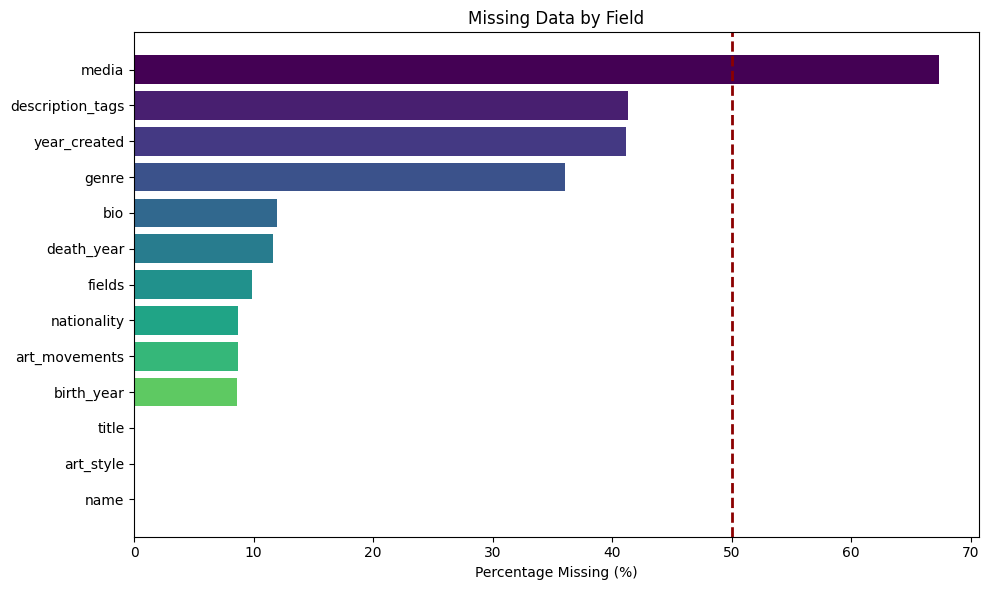

In [ ]:
# Plot of missing metadata fields 
def plot_missing_data(summary):
    total = summary['total_rows']
    
    # Remove total_rows, compute percentages, and sort descending
    fields = {k: v for k, v in summary.items() if k != 'total_rows'}
    percentages = {k: (v / total) * 100 for k, v in fields.items()}
    sorted_items = sorted(percentages.items(), key=lambda x: x[1], reverse=True)
    
    labels = [k.replace('_missing', '') for k, _ in sorted_items]
    values = [v for _, v in sorted_items]

    cmap = plt.cm.viridis
    colors = [cmap(i / max(len(values) - 1, 1)) for i in range(len(values))]

    plt.figure(figsize=(10, 6))
    plt.barh(labels, values, color=colors)
    plt.xlabel("Percentage Missing (%)")
    plt.title("Missing Data by Field")
    plt.gca().invert_yaxis()  

    # Threshold line to indicate fields which have over 50% missing values
    plt.axvline(x=50, linestyle='--', color='darkred', linewidth=2)

    plt.tight_layout()
    plt.show()

plot_missing_data(summary_of_missing_values)

## TF-IDF VEctor Space Model (VSM)

Since TF-IDF ... the following fields where chosen `title, genre, art_style, media, description_tags, artist, and nationality`

Numerical features i.e. all year fields where not handled since they will not be used for TF-IDF, and will be handled in future sections where they are necessary.

### Handling Null and Missing Values

Fields that contain missing values; 

**Painting Details** title, genre, media, description_tags

**Artist Details** nationality

#### Categorical 
**Genre, Nationality**

There are several techniques typically used to handle missing/null values in categorical feilds, these include;

(1) deleting rows with missing values, only used if there are only a few rows and the dataset is large 

(2) replace missing values with the most frequent value i.e. mode

**(3) replace with a constant placeholder e.g., "unknown" by using COALESCE for default values**

(4) predict label using ML e.g., logistic regression model or unsupervised learning e.g., k-Means


In [ ]:
# Replace missing categorical field values with a constant placeholder i.e. "unknown" 
def replace_missing_categorical():
    conn = get_db_connection()
    cur = conn.cursor()

    query = """
    UPDATE paintings_and_artists_metadata_tf_idf
    SET 
        genre = COALESCE(NULLIF(TRIM(genre), ''), 'unknown'),
        nationality = COALESCE(NULLIF(TRIM(nationality), ''), 'unknown');
    """
    cur.execute(query)

    conn.commit()
    cur.close()
    conn.close()

replace_missing_categorical()

# TO-DO: Choose between 1. "unknown" stopword for clean semantic similarity or 2. keep to preserve missing

In [21]:
def is_null_like(value):
    if value is None:
        return True
    
    value = value.strip().lower()
    
    return value in {"", "null", "[null]", "none", "nan", "NaN"}

def replace_missing_categorical(query):
    if is_null_like(query):
        return "unknown"
    
    return query.strip().lower()

#### Multi-Value Fields
**Description Tags, Media**

There are several techniques typically used to handle missing/null values in multi-value feilds, these include;

(1) deleting rows with missing values, only used if there are only a few rows and the dataset is large 

**(2) replace missing values with an empty list i.e. [ ]**

(3) replace with a constant placeholder e.g., "unknown" by using COALESCE for default values

(4) predict label using ML e.g., logistic regression model or unsupervised learning e.g., k-Means

#### Free Text 
**Title**

In terms of NULL handling text is handled the same way as multivalue value fields.

In [ ]:
# Replace missing multi-value fields with '' that corresponds to [] in python, since [] can't be directly stored in the DB
# Replace NULL/empty with empty string with '' since dropping will result in data loss and replacing with "unkown" or 
# "no title" is misleading
def replace_null():
    conn = get_db_connection()
    cur = conn.cursor()

    query = """
    UPDATE paintings_and_artists_metadata_tf_idf
    SET 
        title = COALESCE(NULLIF(TRIM(title), ''), '')
        description_tags = COALESCE(NULLIF(TRIM(description_tags), ''), ''),
        media = COALESCE(NULLIF(TRIM(media), ''), '');
    """

    cur.execute(query)

    conn.commit()
    cur.close()
    conn.close()

replace_null()

In [18]:
# Query null handling for mulit-value fields and text fields
def replace_null(query):
    if is_null_like(query):
        return ""
    
    return query.strip()

#### Normalisation and Cleaning
#### Text, Multi-Value, Categorical Normalisation 

In [10]:
# Load lightweight spaCy model and disable unnecessary components to reduce workload
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

# Conservative stopword set to preserve discriminative tokens and artistic context
BASIC_STOPWORDS = {"the", "a", "an", "of", "in", "on", "at", "and"}

def lemmatisation(text: str) -> list:
    if not text:
        return []

    # Perform tokenisation to split text into linguistically meaningful tokens
    doc = nlp(text)

    tokens = []
    for token in doc:
        text = token.text.strip()

        if not text:
            continue

        # Stopword removal - keep pure numbers since in a title they can be either dates, numbers, etc.., e.g. "no 5"
        if text.lower() in BASIC_STOPWORDS:
            continue

        # Preserve short tokens (e.g. "bb", "i", "iv", "no", "d")
        if len(text) <= 2:
            tokens.append(text.lower())
            continue

        # Preserve proper nouns (names, places, titles)
        if token.pos_ == "PROPN":
            tokens.append(text.lower())
            continue

        # Default lemmatisation to reduce words to their base
        lemma = token.lemma_.strip().lower()

        if lemma:
            tokens.append(lemma)
        
    return tokens

def normalise_text(title: str) -> str:
    # Exit if empty cell
    if not title:
        return ""
    
    # Unicode normalisation i.e. remove accents, convert to lowercase, remove punctuation, and 
    # keep alphanumeric and spaces, collapse extra whitespace
    title = unicodedata.normalize("NFKD", title)
    title = "".join([c for c in title if not unicodedata.combining(c)])

    title = title.lower()
    title = re.sub(r"[^\w\s]", " ", title)
    title = re.sub(r"\s+", " ", title).strip()

    # Exit pipeline if title is an empty string after cleaning 
    if not title:
        return ""
    
    tokens = lemmatisation(title)

    # Reconstruct
    return " ".join(tokens)

def normalise_multi_value(value: str, apply_segmentation: bool = False) -> str:
    # Exit if empty cell
    if not value:
        return ""
    
    tokens = []

    # Split on comma
    for item in value.split(","):
        item = item.strip().lower()

        if not item:
            continue

        # Replace hyphens with space for semantic expansion and collapse internal whitespace
        item = item.replace("-", " ")
        item = re.sub(r"\s+", " ", item).strip()

        # Remove stopwords and exit if empty string after cleaning
        words = [w for w in item.split() if w not in BASIC_STOPWORDS]
        if not words:
            continue

        item = " ".join(words)

        # For description_tags; split conjoined words and join back with space 
        if apply_segmentation and " " not in item:
            # Only split if token looks like a compound, i.e. long (>8) and no digits
            if len(item) > 8 and item.isalpha():
                split_words = wordninja.split(item)

                # To avoid bad splits (e.g. single char fragments)
                if len(split_words) > 1 and all(len(w) > 2 for w in split_words):
                    item = " ".join(split_words)
        
        lemmas = lemmatisation(item)
        tokens.append(" ".join(lemmas))

    # Deduplicate
    seen = set()
    clean_tokens = []
    for t in tokens:
        if t not in seen:
            seen.add(t)
            # Apply _ to preserve multi-word segments in tf-idf
            t = t.replace(" ", "_")

            clean_tokens.append(t)

    return " ".join(clean_tokens)   # space-separated tokens

def normalise_categorical(value: str, field_name: str = "None", prefix: bool = False) -> str:
    # Exit if empty cell
    if not value:
        return ""
    
    value = value.strip().lower()

    # Handle unknown as missing since this creates artificial similarity i.e. will appear similar in TF-IDF
    if value == "unknown":
        return ""

    # Remove punctuation and keep only alphanumeric and spacing, collapse extra whitespace
    value = re.sub(r"[^\w\s]", "", value)
    value = re.sub(r"\s+", " ", value).strip()

    if not value:
        return ""

    # Convert to atomic token and prefix to avoid collisions (this is necessary for art_style and genre only)
    if prefix:
        value = value.replace(" ", "_")
        token = f"{field_name}_{value}"
        return token
    
    token = value.replace(" ", "_")

    return token
            
DEBUG = True              
DEBUG_SAMPLE_RATE = 500   
DEBUG_FIRST_N = 50        

def normalise_database_text_fields_tf_idf():
    conn = get_db_connection()
    cur = conn.cursor(cursor_factory=psycopg2.extras.RealDictCursor)

    # Fetch all rows title, genre, art_style, media, description tags, artist, nationality
    cur.execute("""
        SELECT 
            painting_id,
            title,
            genre,
            art_style,
            media,
            description_tags, 
            artist,
            nationality
        FROM paintings_and_artists_metadata_tf_idf
        ORDER BY painting_id ASC;
    """)

    rows = cur.fetchall()
    total_rows = len(rows)

    # Clean fields according to data type; free text, multi-value, categorical S
    for i, row in enumerate(rows, 1):
        pid = row["painting_id"]
        # Normalisation for free text; title 
        # 1. Lowercase
        # 2. Unicode normalisation (remove accents)
        # 3. Remove punctuation
        # 4. Tokenise (whitespace)
        # 5. Remove stopwords
        # 6. Lemmatise
        clean_title = normalise_text(row["title"])
    
        # Normalisation for multi-value fields; description_tags, media
        # 1. Split on comma
        # 2. Replace hyphens with spaces
        # 3. Lowercase
        # 4. Trim whitespace
        # 5. Remove duplicates
        # 6. Space-Seperated Tokens
        clean_desc_tags = normalise_multi_value(row["description_tags"], apply_segmentation=True)
        clean_media = normalise_multi_value(row["media"])

        # Normalisation for categorical fields; artist, genre, art_style, nationality 
        # they are labels not sentences, i.e. atomic tokens
        # 1. Lowercase
        # 2. Strip whitespace
        # 3. Replace spaces with underscores
        # 4. Remove punctuation
        # 5. Add token prefixing to prevent cross-field semantic collisions for genre and art style
        # 6. Discard unknown since fields with unknown will appear similar 
        clean_artist = normalise_categorical(row["artist"])
        clean_genre = normalise_categorical(row["genre"], field_name="genre", prefix=True)
        clean_style = normalise_categorical(row["art_style"], field_name="style", prefix=True)
        clean_nationality = normalise_categorical(row["nationality"])

        # Debug print statements 
        if DEBUG:
            # Full debug for first few rows
            if i <= DEBUG_FIRST_N:
                print(f"\nROW {i}/{total_rows}, Painting ID: {pid}")

                print("TITLE:")
                print("  Before:", row["title"])
                print("  After: ", clean_title)

                print("DESCRIPTION TAGS:")
                print("  Before:", row["description_tags"])
                print("  After: ", clean_desc_tags)

                print("MEDIA:")
                print("  Before:", row["media"])
                print("  After: ", clean_media)

                print("CATEGORICAL:")
                print("  ARTIST:", row["artist"], "to", clean_artist)
                print("  GENRE:", row["genre"], "to", clean_genre)
                print("  STYLE:", row["art_style"], "to", clean_style)
                print("  NATIONALITY:", row["nationality"], "to", clean_nationality)

            # Periodic progress update
            elif i % DEBUG_SAMPLE_RATE == 0:
                print(f"Processed {i}/{total_rows} rows ({(i/total_rows)*100:.2f}%)")

        # Update DB
        cur.execute("""
            UPDATE paintings_and_artists_metadata_tf_idf
            SET 
                title_clean = %s,
                genre_clean = %s,
                art_style_clean = %s,
                media_clean = %s,
                description_tags_clean = %s,
                artist_clean = %s,
                nationality_clean = %s
            WHERE painting_id = %s
        """, (
            clean_title,
            clean_genre,
            clean_style,
            clean_media,
            clean_desc_tags,
            clean_artist,
            clean_nationality,
            pid
        ))
        print("Finished processing, Painting ID: ", pid)

    conn.commit()
    cur.close()
    conn.close()

In [ ]:
# Normalise Database for TF-IDF VSM 
normalise_database_text_fields_tf_idf()


=== ROW 1/81444 (ID: 1) ===
TITLE:
  BEFORE: Acolman 1
  AFTER:  acolman 1
DESCRIPTION TAGS:
  BEFORE: Photograph,Tree,Monochromephotography,Trunk,Woodyplant,Monochrome,Line,Forest
  AFTER:  photograph tree monochrome_photography trunk woody_plant monochrome line forest
MEDIA:
  BEFORE: 
  AFTER:  
CATEGORICAL:
  ARTIST: Aaron Siskind to aaron_siskind
  GENRE: photo to genre_photo
  STYLE: Abstract Expressionism to style_abstract_expressionism
  NATIONALITY: American to american
Finished processing, Painting ID:  1

=== ROW 2/81444 (ID: 2) ===
TITLE:
  BEFORE: Chicago
  AFTER:  chicago
DESCRIPTION TAGS:
  BEFORE: Photograph,Stockphotography
  AFTER:  photograph stock_photography
MEDIA:
  BEFORE: 
  AFTER:  
CATEGORICAL:
  ARTIST: Aaron Siskind to aaron_siskind
  GENRE: photo to genre_photo
  STYLE: Abstract Expressionism to style_abstract_expressionism
  NATIONALITY: American to american
Finished processing, Painting ID:  2

=== ROW 3/81444 (ID: 3) ===
TITLE:
  BEFORE: Chicago 6
  AFT

### Building the final TF-IDF document vector using Late Feature Fusion


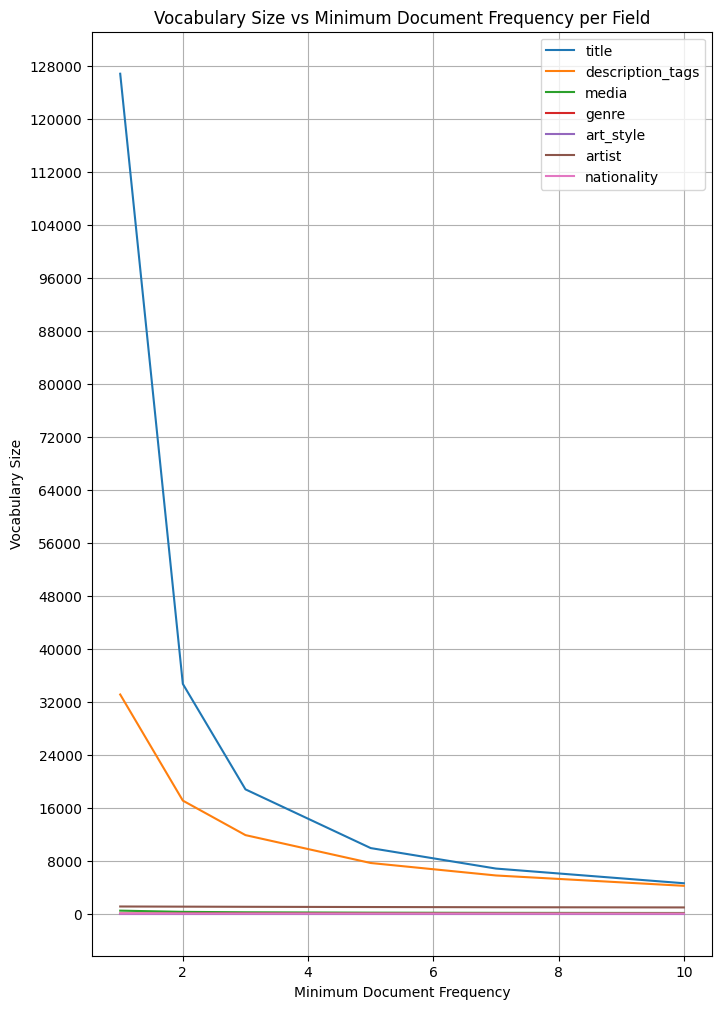

In [11]:
FIELDS = {
    "title": "title_clean",
    "description_tags": "description_tags_clean",
    "media": "media_clean",
    "genre": "genre_clean",
    "art_style": "art_style_clean",
    "artist": "artist_clean",
    "nationality": "nationality_clean"
}

def fetch_normalised_fields():
    conn = get_db_connection()
    cur = conn.cursor(cursor_factory=psycopg2.extras.RealDictCursor)

    # Fetch all rows title, genre, art_style, media, description tags, artist, nationality
    cur.execute("""
        SELECT 
            painting_id,
            title_clean,
            genre_clean,
            art_style_clean,
            media_clean,
            description_tags_clean, 
            artist_clean,
            nationality_clean
        FROM paintings_and_artists_metadata_tf_idf
        ORDER BY painting_id ASC;
    """)

    rows = cur.fetchall()

    cur.close()
    conn.close()

    return rows

def build_corpora(rows):
    corpora = {field: [] for field in FIELDS}

    for row in rows:
        for field, col in FIELDS.items():
            value = row[col] or ""
            corpora[field].append(value)

    return corpora

# Plot Different min_df values to analyse vocab size per field
def plot_vocab_size_per_field(corpora, min_df_values=[1,2,3,5,7,10]):
    results = {field: [] for field in FIELDS}
    
    # Compute vocab sizes for each min_df
    for min_df in min_df_values:
        for field, texts in corpora.items():
            vectorizer = TfidfVectorizer(
                tokenizer=str.split, 
                lowercase=False, 
                preprocessor=None, 
                token_pattern=None, 
                min_df=min_df, 
                max_df=0.8, 
                ngram_range=(1, 2))
            
            X = vectorizer.fit_transform(texts)
            vocab_size = len(vectorizer.vocabulary_)
            
            results[field].append(vocab_size)
    
    # Plot
    plt.figure(figsize=(8, 12))
    
    for field, vocab_sizes in results.items():
        plt.plot(min_df_values, vocab_sizes, label=field)
    
    plt.xlabel("Minimum Document Frequency")
    plt.ylabel("Vocabulary Size")
    plt.title("Vocabulary Size vs Minimum Document Frequency per Field")
    plt.legend()
    plt.grid(True)
    plt.gca().yaxis.set_major_locator(plt.MaxNLocator(nbins=20))
    plt.show()

rows = fetch_normalised_fields()
corpora = build_corpora(rows)
plot_vocab_size_per_field(corpora)

In [12]:
# Manually chosen - change when performing grid search
MIN_DF_CONFIG = {
    "title": 3,               
    "description_tags": 3,    
    "media": 2,             
    "genre": 1,               
    "art_style": 1,           
    "artist": 1,             
    "nationality": 1          
}

def build_tf_idf_per_field(corpora):
    vectorizers = {}
    matrices = {}

    for field, texts in corpora.items():
        print(f"Building TF-IDF for field: {field}")
    
        vectorizer = TfidfVectorizer(
            tokenizer=str.split,            
            lowercase=False,                
            preprocessor=None,              
            token_pattern=None,             
            min_df=MIN_DF_CONFIG[field],    # remove rare noise
            max_df=0.8,                     # remove overly common terms
            ngram_range=(1, 2)              # unigrams and bigrams
        )

        X = vectorizer.fit_transform(texts)

        print(f"  Shape: {X.shape}")
        print(f"  Vocabulary size: {len(vectorizer.vocabulary_)}")

        non_empty = sum(1 for t in texts if t.strip())
        print(f"  Non-empty docs: {non_empty}/{len(texts)}")

        vectorizers[field] = vectorizer
        matrices[field] = X

    return vectorizers, matrices

# Build TF-IDF per field
vectorisers, matrices = build_tf_idf_per_field(corpora)

Building TF-IDF for field: title
  Shape: (81444, 18792)
  Vocabulary size: 18792
  Non-empty docs: 81440/81444
Building TF-IDF for field: description_tags
  Shape: (81444, 11888)
  Vocabulary size: 11888
  Non-empty docs: 47805/81444
Building TF-IDF for field: media
  Shape: (81444, 308)
  Vocabulary size: 308
  Non-empty docs: 26610/81444
Building TF-IDF for field: genre
  Shape: (81444, 52)
  Vocabulary size: 52
  Non-empty docs: 52056/81444
Building TF-IDF for field: art_style
  Shape: (81444, 27)
  Vocabulary size: 27
  Non-empty docs: 81444/81444
Building TF-IDF for field: artist
  Shape: (81444, 1118)
  Vocabulary size: 1118
  Non-empty docs: 81444/81444
Building TF-IDF for field: nationality
  Shape: (81444, 57)
  Vocabulary size: 57
  Non-empty docs: 74346/81444


#### Test Query Vector of Paintings User Interacted with

In [31]:
# Raw Test Query 
query = {
    "painting_id" : "55055",
    "title": "[null]",
    "description_tags": "[null]",
    "media": "ink,paper",
    "artist": "Vincent Van Gogh",
    "genre": "sketch and study",
    "art_style": "[null]",
    "nationality": "[null]"
}

# Handle NULLs/Missing Values 
query["title"] = replace_null(query["title"])
query["description_tags"] = replace_null(query["description_tags"])
query["media"] = replace_null(query["media"])
query["artist"] = replace_missing_categorical(query["artist"])
query["genre"] = replace_missing_categorical(query["genre"])
query["art_style"] = replace_missing_categorical(query["art_style"])
query["nationality"] = replace_missing_categorical(query["nationality"])

# Normalise and Clean
clean_title = normalise_text(query["title"])
clean_desc_tags = normalise_multi_value(query["description_tags"], apply_segmentation=True)
clean_media = normalise_multi_value(query["media"])
clean_artist = normalise_categorical(query["artist"])
clean_genre = normalise_categorical(query["genre"], field_name="genre", prefix=True)
clean_style = normalise_categorical(query["art_style"], field_name="style", prefix=True)
clean_nationality = normalise_categorical(query["nationality"])

query_clean = {
    "painting_id" : "55055",
    "title": clean_title,
    "description_tags": clean_desc_tags,
    "media": clean_media,
    "artist": clean_artist,
    "genre": clean_genre,
    "art_style": clean_style,
    "nationality": clean_nationality
}
print(query_clean)

def vectorise_query_per_field(query_dict, vectorisers):
    query_vectors = {}

    for field, vectorizer in vectorisers.items():
        text = query_dict.get(field, "")
        query_vectors[field] = vectorizer.transform([text])

    return query_vectors

{'painting_id': '55055', 'title': '', 'description_tags': '', 'media': 'ink paper', 'artist': 'vincent_van_gogh', 'genre': 'genre_sketch_and_study', 'art_style': '', 'nationality': ''}


#### Cosine-Similarity and Late Feature Fusion

In [32]:
# Weights per Feild according to importance - change using grid search
WEIGHTS = {
    "title": 0.3,
    "description_tags": 0.15,
    "media": 0.15,
    "genre": 0.2,
    "art_style": 0.2,
    "artist": 0.1,
    "nationality": 0.1
}

def compute_similarity_per_field(query_vectors, matrices):
    similarities = {}

    for field in matrices:
        sim = cosine_similarity(query_vectors[field], matrices[field])
        similarities[field] = sim.flatten()  
    return similarities

def weighted_late_fusion(similarities, weights):
    num_docs = len(next(iter(similarities.values())))
    final_scores = np.zeros(num_docs)

    for field, sim in similarities.items():
        weight = weights.get(field, 0)
        final_scores += weight * sim

    return final_scores

#### Retreival and Ranking 

In [35]:
def get_top_k(final_scores, query_index, k=30):

    # Exclude index of query painting from top k
    final_scores[query_index] = -np.inf
    top_indices = np.argsort(final_scores)[::-1][:k]

    return top_indices, final_scores[top_indices]

painting_id_to_index = {
    row["painting_id"]: idx
    for idx, row in enumerate(rows)
}
#query_index = painting_id_to_index[query_clean["painting_id"]]

In [36]:
query_index = int(query_clean["painting_id"])
def recommend(query_dict, vectorisers, matrices, weights, query_painting_id, k=10):
    query_vectors = vectorise_query_per_field(query_dict, vectorisers)
    similarities = compute_similarity_per_field(query_vectors, matrices)
    final_scores = weighted_late_fusion(similarities, weights)
    top_indices, scores = get_top_k(final_scores, query_painting_id, k)
    return top_indices, scores, similarities

# Take Cleaned Query
top_indices, scores, similarities = recommend(
    query_clean, vectorisers, matrices, WEIGHTS, query_index, k=10)

def fetch_paintings(painting_ids):
    conn = get_db_connection()
    cur = conn.cursor(cursor_factory=psycopg2.extras.RealDictCursor)

    # Preserve order 
    cur.execute("""
        SELECT 
            painting_id,
            title,
            artist,
            genre, 
            art_style,
            media,
            description_tags,
            nationality,
            image_path
        FROM paintings_and_artists_metadata_tf_idf
        WHERE painting_id = ANY(%s)
        ORDER BY array_position(%s, painting_id);
    """, (painting_ids, painting_ids))

    rows = cur.fetchall()

    cur.close()
    conn.close()

    return rows

1. Painting ID: 55054, Score: 1.2000
   Title: Public Garden With Couple And Blue Fir Tree The Poet S Garden Iii
   Artist: Vincent Van Gogh
   Genre: unknown
   Art Style: Post Impressionism
   Media: 
   Description Tags: 
   Nationality: Dutch
   Image Path: paintings/Post_Impressionism/vincent-van-gogh_public-garden-with-couple-and-blue-fir-tree-the-poet-s-garden-iii-1888.jpg


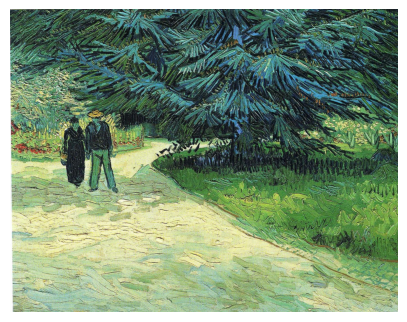

2. Painting ID: 55052, Score: 1.0078
   Title: Public Garden With A Couple And A Blue Fir Tree
   Artist: Vincent Van Gogh
   Genre: sketch and study
   Art Style: Post Impressionism
   Media: ink,paper
   Description Tags: Gardens-And-Parks,Text,Handwriting,Font
   Nationality: Dutch
   Image Path: paintings/Post_Impressionism/vincent-van-gogh_public-garden-with-a-couple-and-a-blue-fir-tree-1888.jpg


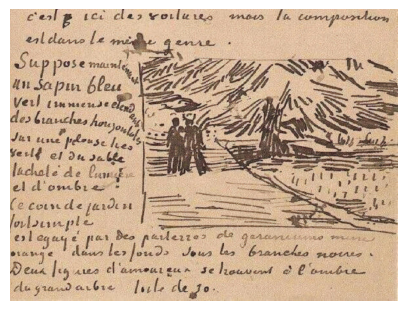

3. Painting ID: 55050, Score: 0.9655
   Title: Prisoners Exercising Prisoners Round
   Artist: Vincent Van Gogh
   Genre: unknown
   Art Style: Post Impressionism
   Media: 
   Description Tags: 
   Nationality: Dutch
   Image Path: paintings/Post_Impressionism/vincent-van-gogh_prisoners-exercising-prisoners-round-1890.jpg


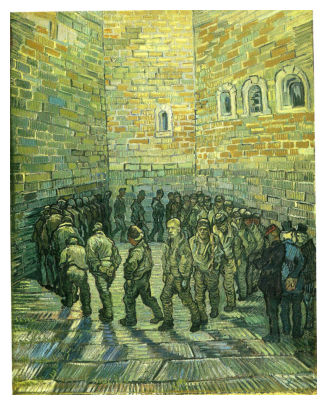

4. Painting ID: 55051, Score: 0.9415
   Title: Public Garden With A Corner Of The Yellow House
   Artist: Vincent Van Gogh
   Genre: sketch and study
   Art Style: Post Impressionism
   Media: ink,paper
   Description Tags: Gardens-And-Parks,Arles,Tree,Botany
   Nationality: Dutch
   Image Path: paintings/Post_Impressionism/vincent-van-gogh_public-garden-with-a-corner-of-the-yellow-house-1888.jpg


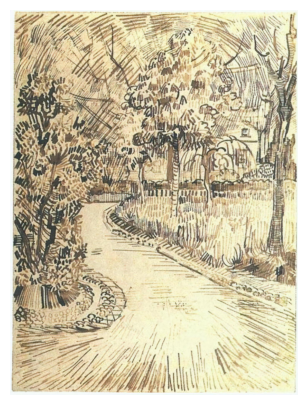

5. Painting ID: 55078, Score: 0.9178
   Title: Roses And Beetle
   Artist: Vincent Van Gogh
   Genre: flower painting
   Art Style: Post Impressionism
   Media: oil,canvas
   Description Tags: Flowers-And-Plants,Insects,Beetles,Flower,Plant,Gardenroses
   Nationality: Dutch
   Image Path: paintings/Post_Impressionism/vincent-van-gogh_roses-and-beetle-1890.jpg


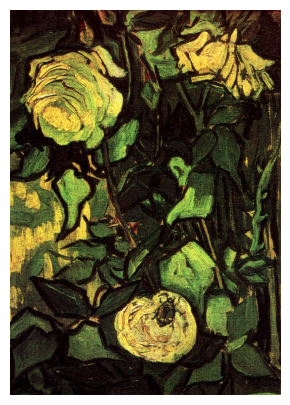

6. Painting ID: 55301, Score: 0.9144
   Title: The Garden Of St Paul S Hospital At St Remy
   Artist: Vincent Van Gogh
   Genre: unknown
   Art Style: Post Impressionism
   Media: 
   Description Tags: 
   Nationality: Dutch
   Image Path: paintings/Post_Impressionism/vincent-van-gogh_the-garden-of-st-paul-s-hospital-at-st-remy-1889.jpg


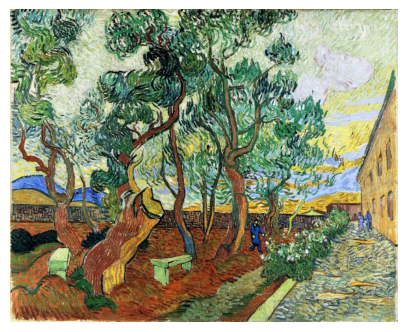

7. Painting ID: 54893, Score: 0.8192
   Title: Meadow With Flowers
   Artist: Vincent Van Gogh
   Genre: landscape
   Art Style: Post Impressionism
   Media: pencil,ink,paper
   Description Tags: Fields-And-Plains,Barley,Field,Plant,Grassfamily,Grass,Rye,Crop
   Nationality: Dutch
   Image Path: paintings/Post_Impressionism/vincent-van-gogh_meadow-with-flowers-1888.jpg


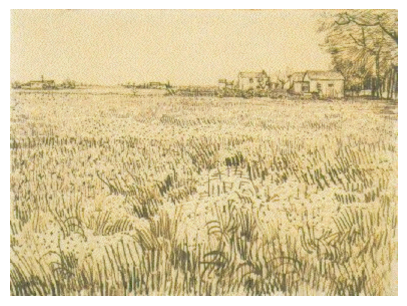

8. Painting ID: 54934, Score: 0.7980
   Title: Orchard And House With Orange Roof  1
   Artist: Vincent Van Gogh
   Genre: unknown
   Art Style: Post Impressionism
   Media: 
   Description Tags: 
   Nationality: Dutch
   Image Path: paintings/Post_Impressionism/vincent-van-gogh_orchard-and-house-with-orange-roof-1888-1.jpg


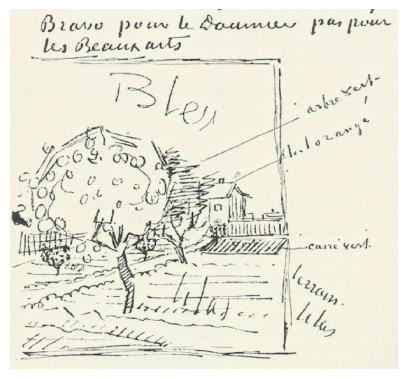

9. Painting ID: 54945, Score: 0.7926
   Title: Orchard Surrounded By Cypresses
   Artist: Vincent Van Gogh
   Genre: sketch and study
   Art Style: Post Impressionism
   Media: 
   Description Tags: Gardens-And-Parks,Sketch
   Nationality: Dutch
   Image Path: paintings/Post_Impressionism/vincent-van-gogh_orchard-surrounded-by-cypresses-1888.jpg


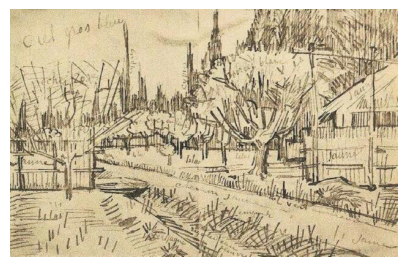

10. Painting ID: 54952, Score: 0.7797
   Title: Outskirts Of Paris Near Montmartre
   Artist: Vincent Van Gogh
   Genre: cityscape
   Art Style: Post Impressionism
   Media: gouache,pastel,ink,watercolor,paper
   Description Tags: Paris,Margins-And-Wastelands
   Nationality: Dutch
   Image Path: paintings/Post_Impressionism/vincent-van-gogh_outskirts-of-paris-near-montmartre-1887.jpg


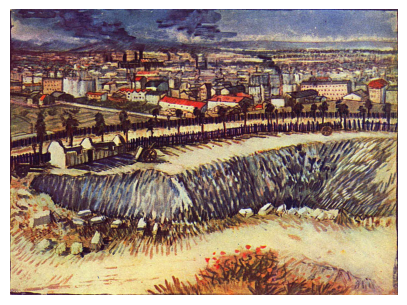

In [ ]:
# Fetch the top painting metadata and image paths from the database
painting_ids = top_indices.tolist()
paintings = fetch_paintings(painting_ids)

for rank, painting in enumerate(paintings, start=1):
    print(f"{rank}. Painting ID: {painting['painting_id']}, Score: {scores[rank-1]:.4f}")
    print(f"   Title: {painting['title']}")
    print(f"   Artist: {painting['artist']}")
    print(f"   Genre: {painting['genre']}")
    print(f"   Art Style: {painting['art_style']}")
    print(f"   Media: {painting['media']}")
    print(f"   Description Tags: {painting['description_tags']}")
    print(f"   Nationality: {painting['nationality']}")
    print(f"   Image Path: {painting['image_path']}")

    image_path = painting.get('image_path')
    if image_path:
        image_path = (dataset_path / image_path).resolve()
        image = cv2.imread(str(image_path))
        if image is not None:
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            plt.figure(figsize=(5, 5))
            plt.imshow(image_rgb)
            plt.axis('off')
            plt.show()
        else:
            print(f"Unable to load image from path: {image_path}")
    else:
        print("No image_path available for this painting.")

#### Per-Field Contribution Breakdown

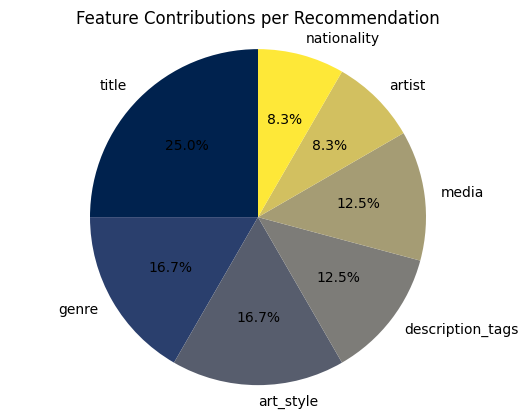

In [ ]:
def compute_feature_contributions(similarities, weights, retrieved_doc_idx):
    contributions = {}
    total = 0

    for field in similarities:
        value = weights[field] * similarities[field][retrieved_doc_idx]
        contributions[field] = value
        total += value

    # Normalise to percentages
    normalised = {
        field: (value / total if total != 0 else 0)
        for field, value in contributions.items()
    }

    return contributions, normalised, total

# Compute contributions
retrieved_doc_index = top_indices[0]
contribs, norm_contribs, total = compute_feature_contributions(similarities, WEIGHTS, retrieved_doc_index)
sorted_items = sorted(norm_contribs.items(), key=lambda x: x[1], reverse=True)

labels = [k.replace('_missing', '') for k, _ in sorted_items]
values = [v for _, v in sorted_items]

cmap = plt.cm.cividis
colors = [cmap(i / max(len(values) - 1, 1)) for i in range(len(values))]

# Plot pie chart
plt.figure()
plt.pie(
    values,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',   
    startangle=90       
)

plt.title("Feature Contributions per Recommendation")
plt.axis('equal') 
plt.show()

## Evaluation 

**Predictive Quality Metrics**; Precision@k, Recall@k, F1-score@k

**Ranking Quality Metrics**; MRR, MAP, NDCG

**Behavioural Metrics**; Diversity, Novelty, Serendipity, Popularity bias 

### Predictive Quality Metrics
Such metrics reflect the “correctness” of recommendations and show how well the system finds relevant items

#### Precision@k

This metric measures the proportion of relevant items among the top k items

#### Recall@k
This metric measures the coverage of relevant items in the top k 

#### F1-Score@k
This metric measures the coverage of relevant items in the top k 

#### Confusion Matrix

### Ranking Quality Metrics

### Behavioural Metrics

In [37]:
# Build a query using all rows of the database to perform a dataset-level estimate of diversity
def build_query(row):
    query = {
        "painting_id": row["painting_id"],
        "title": replace_null(row["title_clean"]),
        "description_tags": replace_null(row["description_tags_clean"]),
        "media": replace_null(row["media_clean"]),
        "artist": replace_missing_categorical(row["artist_clean"]),
        "genre": replace_missing_categorical(row["genre_clean"]),
        "art_style": replace_missing_categorical(row["art_style_clean"]),
        "nationality": replace_missing_categorical(row["nationality_clean"])
    }

    query_clean = {
        "painting_id": int(query["painting_id"]),
        "title": normalise_text(query["title"]),
        "description_tags": normalise_multi_value(query["description_tags"], apply_segmentation=True),
        "media": normalise_multi_value(query["media"]),
        "artist": normalise_categorical(query["artist"]),
        "genre": normalise_categorical(query["genre"], field_name="genre", prefix=True),
        "art_style": normalise_categorical(query["art_style"], field_name="style", prefix=True),
        "nationality": normalise_categorical(query["nationality"])
    }

    return query_clean

#### Diversity 

intra-list similarity


In [38]:
# Since diversity can only be computed using a single vector per item (painting), perform 
# weighted fusion 
def build_weighted_item_vectors(matrices, weights):
    # matrices[field] = (num_items, num_features_field)
    weighted_matrices = []
    
    for field, matrix in matrices.items():
        weight = weights.get(field, 0)
        weighted_matrices.append(matrix * weight)
    
    # Concatenate all fields into one vector
    return hstack(weighted_matrices)

# Compute intra-list similarity i.e. diversity
def compute_diversity(top_indices, item_vectors):
    vectors = item_vectors[top_indices]  # shape (K, D)
    
    sim_matrix = cosine_similarity(vectors)
    
    K = len(top_indices)
    
    # Take upper triangle, hence excluding the diagonal
    pairwise_sims = sim_matrix[np.triu_indices(K, k=1)]
    
    ils = np.mean(pairwise_sims) if len(pairwise_sims) > 0 else 0
    
    diversity = 1 - ils
    
    return diversity

def evaluate_diversity(rows, vectorisers, matrices, weights, item_vectors, k=10):
    diversity_scores = []

    # Build query for each painting, get recommendations, and compute diversity per recommendation list
    for row in rows:
        query_clean = build_query(row)
        query_id = int(query_clean["painting_id"])
        top_indices, _, _ = recommend(query_clean, vectorisers, matrices, weights, query_id, k)
        diversity = compute_diversity(top_indices, item_vectors)
        diversity_scores.append(diversity)

    # Average diversity across all queries
    return np.mean(diversity_scores)

In [ ]:
rows = fetch_normalised_fields()
corpora = build_corpora(rows)
vectorisers, matrices = build_tf_idf_per_field(corpora)

item_vectors = build_weighted_item_vectors(matrices, WEIGHTS)
item_vectors = normalize(item_vectors, norm='l2')

diversity_score = evaluate_diversity(rows, vectorisers, matrices, WEIGHTS, item_vectors, k=10)

print("Average Diversity:", diversity_score)

Building TF-IDF for field: title
  Shape: (81444, 18792)
  Vocabulary size: 18792
  Non-empty docs: 81440/81444
Building TF-IDF for field: description_tags
  Shape: (81444, 11888)
  Vocabulary size: 11888
  Non-empty docs: 47805/81444
Building TF-IDF for field: media
  Shape: (81444, 308)
  Vocabulary size: 308
  Non-empty docs: 26610/81444
Building TF-IDF for field: genre
  Shape: (81444, 52)
  Vocabulary size: 52
  Non-empty docs: 52056/81444
Building TF-IDF for field: art_style
  Shape: (81444, 27)
  Vocabulary size: 27
  Non-empty docs: 81444/81444
Building TF-IDF for field: artist
  Shape: (81444, 1118)
  Vocabulary size: 1118
  Non-empty docs: 81444/81444
Building TF-IDF for field: nationality
  Shape: (81444, 57)
  Vocabulary size: 57
  Non-empty docs: 74346/81444


#### Novelty 
inverse popularity

#### Serendipity 
unexpectedness vs baseline


#### Popularity bias 
distribution skew

### Grid-Search for WEIGHTS and min_df

In [ ]:
# Perform a grid-search for feild weights and for min_df for titles, description_tags, 

### BERT

#### 1. Preprocessing; Validation Checks (already done), Null handling, and Normalisation

#### 2. Pipeline; (1) *word2vec (BERT)* - (2) *clustering (k-NN)* - (3) *recommendation*

#### 3. Evaluation; LIME, SHAP, CLuster Interpretability, Recommendation Interpretation, and Percent of Correct Recommendations

Fields that contain missing values; 

**Painting Details** title, year_created, genre, media, description_tags

**Artist Details** birth_year, death_year, nationality, feilds, art_movements, bio

#### Text, Multi-Value, Categorcial, Numerical

#### Numerical Features
**Year Created, Birth Year, Death Year**

In [ ]:
#